# Train and evaluate LightGBM Classifier

Trains a standard `LGBMClassifier` per fold (`src/peak_risk/LightGBM_Classifier.py`), row-wise
over (fsa, forecast_timestamp, horizon), predicting whether an hour's real consumption exceeds
the peak threshold (`src/common/peak_risk.py`). Features: the regressor's forecasted
consumption, calendar features of the forecast timestamp, and weather/lag/episode features
observed at the origin timestamp only, never the future hour's real weather. Evaluated with
`src/common/metrics.py`.

In [12]:
# Jupyter's cwd is the notebook's folder, not the repo root, so "from src.common..." below
# needs the repo root on sys.path. This walks up parent folders until it finds requirements.txt
# (which only exists at the repo root) and adds that folder to sys.path.
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "requirements.txt").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (requirements.txt not found)")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

WindowsPath('c:/workspace/CAPSTONE/ontario-electricity-peak-risk')

In [13]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score

from src.common.data_loading import INTERIM_DIR, save_interim_dataset
from src.common.folds import FOLDS
from src.common.metrics import (
    calibration_table,
    classification_metrics_by_group,
    classification_summary_metrics,
    top_k_capture_rate,
)
from src.peak_risk.LightGBM_Classifier import predict_long_format, train_fold

pd.set_option("display.max_columns", 50)

## 1. Load the engineered dataset

Loads `fsa_hourly_features.parquet`. `train_fold` builds everything else per fold: the
regressor's forecast, the calendar/weather/lag feature table, and the peak labels.

In [14]:
dataset = pd.read_parquet(INTERIM_DIR / "fsa_hourly_features.parquet")
dataset.shape

(262944, 88)

## 2. Train and predict, one fold at a time

Train and predict per fold, reshaped to the peak-risk contract (`fsa`, `forecast_timestamp`,
`actual_peak`, `peak_probability`, `predicted_peak`, `model_name`). `prevalence` is the real
peak share of that fold's test year, useful context for the sections below.

In [15]:
fold_forecasts = []
fold_summary = []
for fold in FOLDS:
    t0 = time.time()
    model, feature_columns, test = train_fold(dataset, fold)
    train_seconds = time.time() - t0

    forecast = predict_long_format(model, feature_columns, test)
    forecast.insert(0, "fold", fold.number)
    fold_forecasts.append(forecast)

    fold_summary.append(
        {
            "fold": fold.number,
            "test_year": fold.test_year,
            "train_seconds": round(train_seconds, 1),
            "n_predictions": len(forecast),
            "prevalence": round(forecast["actual_peak"].mean(), 4),
            **classification_summary_metrics(forecast),
        }
    )

all_forecasts = pd.concat(fold_forecasts, ignore_index=True)
pd.DataFrame(fold_summary)

,fold,test_year,train_seconds,n_predictions,prevalence,pr_auc,roc_auc,brier,precision,recall,f1
0,1,2023,54.8,1261440,0.1096,0.933478,0.974679,0.015730,0.978184,0.863386,0.917207
1,2,2024,95.0,1264896,0.0400,0.993188,0.999528,0.004558,0.886389,0.988899,0.934842
2,3,2025,120.5,1259640,0.0694,0.984149,0.997145,0.006270,0.936839,0.958653,0.947621


## 3. Aggregated metrics across folds

Mean, median, and standard deviation of each metric across the 3 folds.

In [16]:
per_fold_metrics = pd.DataFrame(fold_summary)[
    ["pr_auc", "roc_auc", "brier", "precision", "recall", "f1"]
]
per_fold_metrics.agg(["mean", "median", "std"]).round(4)

,pr_auc,roc_auc,brier,precision,recall,f1
mean,0.9703,0.9905,0.0089,0.9338,0.9370,0.9332
median,0.9841,0.9971,0.0063,0.9368,0.9587,0.9348
std,0.0322,0.0137,0.0060,0.0460,0.0655,0.0153


## 4. Metrics by forecast horizon

Same question as the regressor notebook (Día 4, section 4): does classifying further-ahead
hours get harder, since it leans on a forecast that gets less accurate at longer horizons?

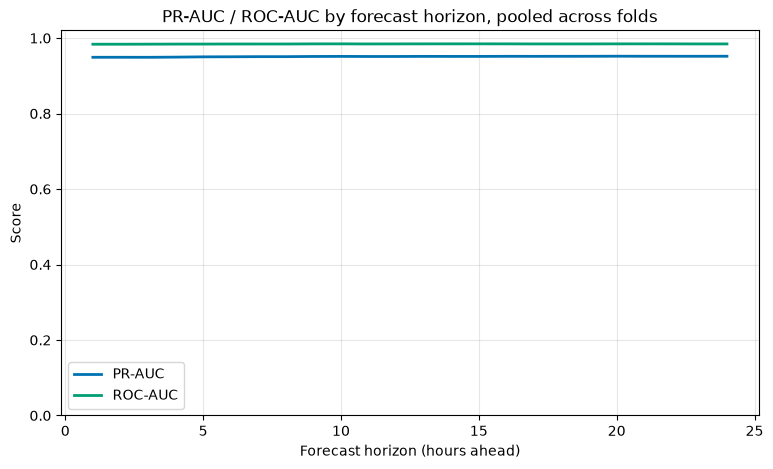

In [17]:
horizon_metrics = classification_metrics_by_group(all_forecasts, "horizon")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(horizon_metrics["horizon"], horizon_metrics["pr_auc"], label="PR-AUC", color="#0072B2", linewidth=2)
ax.plot(horizon_metrics["horizon"], horizon_metrics["roc_auc"], label="ROC-AUC", color="#009E73", linewidth=2)
ax.set_xlabel("Forecast horizon (hours ahead)")
ax.set_ylabel("Score")
ax.set_title("PR-AUC / ROC-AUC by forecast horizon, pooled across folds")
ax.set_ylim(0, 1.02)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Both curves stay flat across all 24 horizons (PR-AUC ~0.95, ROC-AUC ~0.98-0.99). Unlike the
regressor, the classifier does not get worse at longer horizons: calendar/season features
(always exactly known) already carry most of the signal for "is this a typical peak time," so a
less accurate forecast at h+24 barely dents its ranking.

## 5. Top-K capture rate

Share of true peak hours caught within the top `k_fraction` highest-probability predictions.
The raw number depends on prevalence: if a fold's real peak rate exceeds `k_fraction`, not even
a perfect model can catch every peak in that small a slice. Each capture rate is compared
against that ceiling (`min(1, k_fraction / prevalence)`) to see how close to best-possible the
model actually gets.

In [18]:
topk_rows = []
for fold in FOLDS:
    fold_forecast = all_forecasts[all_forecasts["fold"] == fold.number]
    prevalence = fold_forecast["actual_peak"].mean()
    for k_fraction in (0.025, 0.05):
        capture = top_k_capture_rate(fold_forecast, k_fraction)
        ceiling = min(1.0, k_fraction / prevalence)
        topk_rows.append(
            {
                "fold": fold.number,
                "k_fraction": k_fraction,
                "prevalence": round(prevalence, 4),
                "capture_rate": round(capture, 4),
                "ceiling": round(ceiling, 4),
                "pct_of_ceiling": round(capture / ceiling * 100, 1),
            }
        )
pd.DataFrame(topk_rows)

,fold,k_fraction,prevalence,capture_rate,ceiling,pct_of_ceiling
0,1,0.025,0.1096,0.2281,0.2281,100.0
1,1,0.050,0.1096,0.4550,0.4562,99.7
2,2,0.025,0.0400,0.6246,0.6246,100.0
3,2,0.050,0.0400,0.9971,1.0000,99.7
4,3,0.025,0.0694,0.3600,0.3600,100.0
5,3,0.050,0.0694,0.7156,0.7200,99.4


The model lands at 99.4-100% of the ceiling in every fold, at both 2.5% and 5%. The raw capture
numbers (23-100%) look inconsistent at first glance, but they track prevalence, not model
quality; against the ceiling, every fold tells the same story: near-perfect ranking.

## 6. Calibration

Mean predicted probability vs. actual peak rate, 10 bins, pooled across folds.
`class_weight="balanced"` handles the class imbalance (peaks are ~4-11% of hours) but trades
off calibration: probabilities do not always match the true rate, even though ranking
(section 5) stays strong.

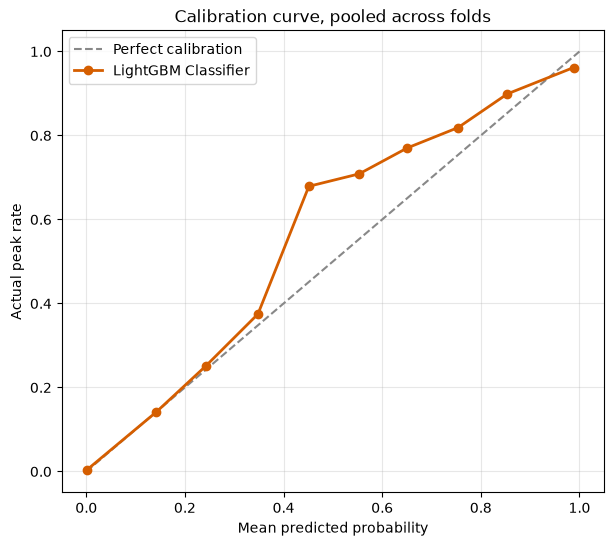

,bin,mean_predicted,actual_rate,n
0,"(-0.002, 0.1]",0.001788,0.004395,3487871
1,"(0.1, 0.2]",0.141756,0.141440,17237
2,"(0.2, 0.3]",0.241886,0.250667,5625
3,"(0.3, 0.4]",0.348084,0.374925,3342
4,"(0.4, 0.5]",0.451328,0.679031,3882
5,"(0.5, 0.6]",0.553371,0.708667,4500
6,"(0.6, 0.7]",0.650952,0.770407,6211
7,"(0.7, 0.8]",0.753935,0.818881,8188
8,"(0.8, 0.9]",0.853779,0.899056,15682
9,"(0.9, 1.0]",0.987956,0.961746,233438


In [19]:
calibration = calibration_table(all_forecasts)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="#888888", label="Perfect calibration")
ax.plot(
    calibration["mean_predicted"], calibration["actual_rate"],
    marker="o", color="#D55E00", linewidth=2, label="LightGBM Classifier",
)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Actual peak rate")
ax.set_title("Calibration curve, pooled across folds")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

calibration

The curve sits above the diagonal everywhere, most noticeably at 0.4-0.6 predicted, where the
real rate is 68-71%. It tightens toward the extremes. This is the cost of
`class_weight="balanced"`: probabilities skew low to raise recall on the rare peak class, so
`peak_probability` should not be read as a literal chance. Ranking (sections 4-5) is
unaffected.

## 7. Verify the 144-probability contract

Every origin timestamp should produce exactly 144 predictions: 6 FSA x 24 horizons.
(`origin_timestamp`/`horizon` are extra diagnostic columns, not part of the contract.) Expected
exception: `train_fold` drops rows with no real `actual` to compare against, only in fold 3's
last day of 2025, the same tail from the regressor's notebook (Día 4, section 5).

In [20]:
run_sizes = all_forecasts.groupby(["fold", "origin_timestamp"], observed=True).size()
short_runs = run_sizes[run_sizes < 144]

full_runs = run_sizes.drop(short_runs.index)
assert (full_runs == 144).all(), "every other origin timestamp should produce 6 FSA x 24 horizons"
assert (short_runs.index.get_level_values("fold") == 3).all()
assert short_runs.index.get_level_values("origin_timestamp").min() >= pd.Timestamp("2025-12-31")

print(len(full_runs), "origin timestamps with exactly 144 predictions")
print(len(short_runs), "origin timestamps short of 144, all in fold 3's last day of 2025")

26280 origin timestamps with exactly 144 predictions
23 origin timestamps short of 144, all in fold 3's last day of 2025


## 8. Metrics by FSA

Pooled across all 3 folds, to see whether any zone is harder to classify than the rest.

In [21]:
classification_metrics_by_group(all_forecasts, "fsa")

,fsa,pr_auc,roc_auc,brier,precision,recall,f1
0,L4T,0.968991,0.998329,0.004119,0.891139,0.967698,0.927842
1,M5R,0.996168,0.998830,0.001023,0.977000,0.989935,0.983425
2,M5S,0.999300,0.999977,0.000651,0.975763,0.991536,0.983586
3,M6G,0.984814,0.998130,0.005910,0.917290,0.975393,0.945450
4,M9R,0.991568,0.997228,0.001917,0.964855,0.986146,0.975384
5,M9W,0.940208,0.967959,0.039480,0.948036,0.861330,0.902606


## 9. Feature importance: is weather a direct driver?

Weather clearly affects consumption in reality (Día 2's temperature U-shape), but that does not
mean the models lean on it directly. Checked with gain-based importance (how much a feature
reduces error, not just how often it's used) on fold 3, both models.

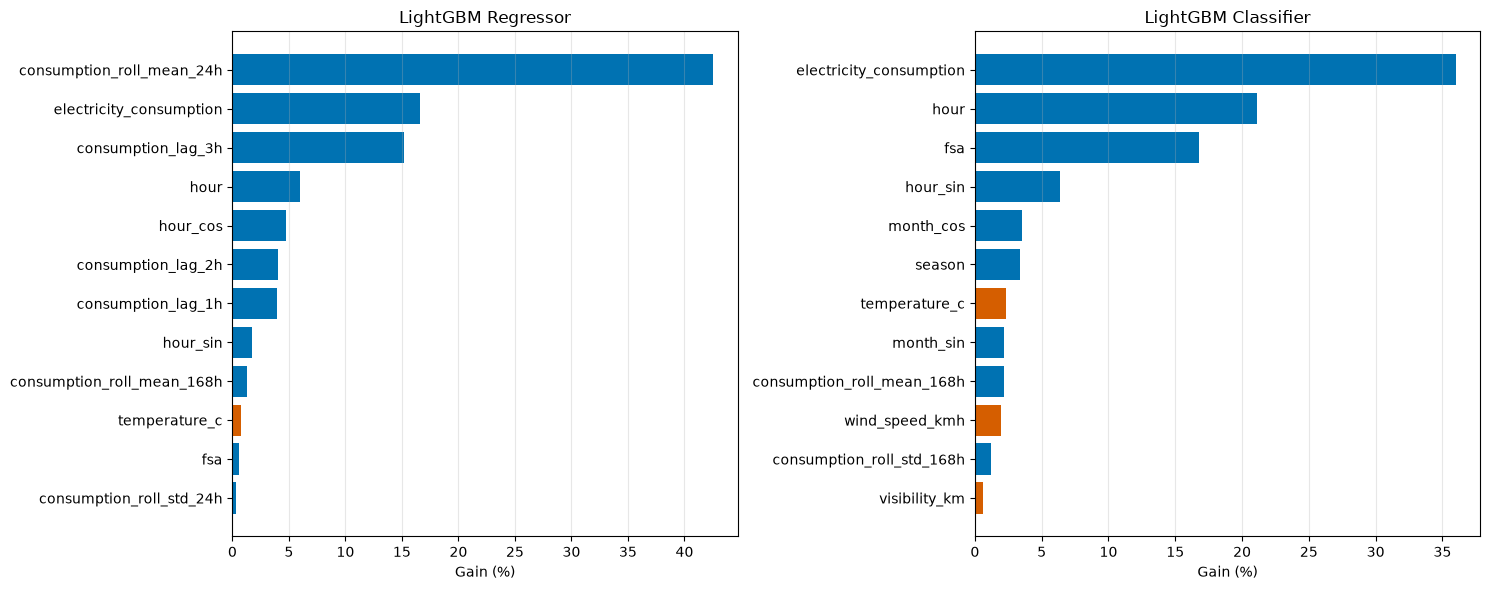

Weather total gain: regressor 1.02 %
Weather total gain: classifier 5.41 %


In [22]:
from src.forecast.LightGBM_Regressor import train_fold as train_regressor_fold

WEATHER_COLUMNS = {
    "temperature_c", "relative_humidity_pct", "precipitation_mm", "wind_speed_kmh",
    "visibility_km", "heat_episode_hours", "cold_episode_hours",
}
fold_3 = FOLDS[2]

regressor_model, regressor_columns, _ = train_regressor_fold(
    dataset, fold_3, model_params={"importance_type": "gain"}
)
regressor_importance = pd.Series(
    np.mean([est.feature_importances_ for est in regressor_model.estimators_], axis=0),
    index=regressor_columns,
)
regressor_importance = (regressor_importance / regressor_importance.sum() * 100).sort_values(ascending=False)

classifier_model, classifier_columns, _ = train_fold(dataset, fold_3, model_params={"importance_type": "gain"})
classifier_importance = pd.Series(classifier_model.feature_importances_, index=classifier_columns)
classifier_importance = (classifier_importance / classifier_importance.sum() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, importance, title in [
    (axes[0], regressor_importance, "LightGBM Regressor"),
    (axes[1], classifier_importance, "LightGBM Classifier"),
]:
    top = importance.head(12).iloc[::-1]
    colors = ["#D55E00" if name in WEATHER_COLUMNS else "#0072B2" for name in top.index]
    ax.barh(top.index, top.to_numpy(), color=colors)
    ax.set_xlabel("Gain (%)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Weather total gain: regressor", round(regressor_importance[regressor_importance.index.isin(WEATHER_COLUMNS)].sum(), 2), "%")
print("Weather total gain: classifier", round(classifier_importance[classifier_importance.index.isin(WEATHER_COLUMNS)].sum(), 2), "%")

Both models lean overwhelmingly on recent consumption and time-of-day. Weather (orange bars)
totals ~1% of gain in the regressor, ~5% in the classifier; `temperature_c` leads but stays
minor, and `heat_episode_hours`/`cold_episode_hours` barely register.

This does not contradict the Día 2 EDA. Weather's effect is real but already absorbed by
cheaper features before the model needs the raw reading: calendar (hour, month, season) already
predicts when it tends to be hot or cold, and lags already carry weather's effect through the
last few hours of actual consumption. The model reads weather secondhand, so its own direct
contribution comes out small even though the underlying driver is real.

## 10. Does the classifier add value over a simple threshold rule?

Internal check, not the team's baseline model (a separate Naïve/Logistic Regression pair on
another branch). It only asks whether training a full `LGBMClassifier` was worth it for our own
two-stage design, against the simplest rule: flag a peak whenever the regressor's forecast
crosses the same threshold. No new model, just a threshold on a number already computed. Brier
is skipped since the score isn't a real probability, only a rank for PR-AUC/ROC-AUC.

In [23]:
naive_rows = []
for fold in FOLDS:
    _, _, test = train_fold(dataset, fold)
    actual = test["actual_peak"].to_numpy()
    score = test["forecast_consumption"].to_numpy()
    predicted = (test["forecast_consumption"] > test["peak_threshold"]).astype(int).to_numpy()
    naive_rows.append(
        {
            "fold": fold.number,
            "model": "naive_threshold",
            "pr_auc": average_precision_score(actual, score),
            "roc_auc": roc_auc_score(actual, score),
            "precision": precision_score(actual, predicted, zero_division=0),
            "recall": recall_score(actual, predicted, zero_division=0),
            "f1": f1_score(actual, predicted, zero_division=0),
        }
    )

naive_table = pd.DataFrame(naive_rows)
classifier_table = pd.DataFrame(fold_summary)[
    ["fold", "pr_auc", "roc_auc", "precision", "recall", "f1"]
].assign(model="LightGBM_Classifier")

comparison = pd.concat([naive_table, classifier_table]).sort_values(["fold", "model"]).reset_index(drop=True)
comparison

,fold,model,pr_auc,roc_auc,precision,recall,f1
0,1,LightGBM_Classifier,0.933478,0.974679,0.978184,0.863386,0.917207
1,1,naive_threshold,0.481179,0.892832,0.892448,0.729218,0.802618
2,2,LightGBM_Classifier,0.993188,0.999528,0.886389,0.988899,0.934842
3,2,naive_threshold,0.351341,0.840108,0.672632,0.539771,0.598922
4,3,LightGBM_Classifier,0.984149,0.997145,0.936839,0.958653,0.947621
5,3,naive_threshold,0.362587,0.782490,0.674455,0.596262,0.632953


Yes, clearly: PR-AUC roughly doubles the naive rule's in every fold (0.93 vs 0.48, 0.99 vs 0.35,
0.98 vs 0.36), recall stays well ahead too (0.86-0.99 vs 0.54-0.73). The naive rule's weak
recall lines up with the regressor's known bias (Día 4, section 8): an underestimated forecast
misses real peaks that a hard threshold alone can't catch. The classifier recovers that gap by
learning from the full context, not just one number, so building it was worth the extra step.

## 11. Save predictions

Saves the long-format peak-risk predictions from all 3 folds to
`data/interim/lightgbm_classifier_predictions.parquet`.

In [24]:
output_path = save_interim_dataset(all_forecasts, filename="lightgbm_classifier_predictions.parquet")
output_path

WindowsPath('C:/workspace/CAPSTONE/ontario-electricity-peak-risk/data/interim/lightgbm_classifier_predictions.parquet')